REPORTE DE CLASIFICACIÓN (MODELO SIN COORDENADAS)
              precision    recall  f1-score   support

   no_riesgo       0.67      0.62      0.64      6613
      riesgo       0.68      0.73      0.70      7324

    accuracy                           0.68     13937
   macro avg       0.67      0.67      0.67     13937
weighted avg       0.68      0.68      0.67     13937

Área Bajo la Curva ROC (AUC-ROC): 0.7367



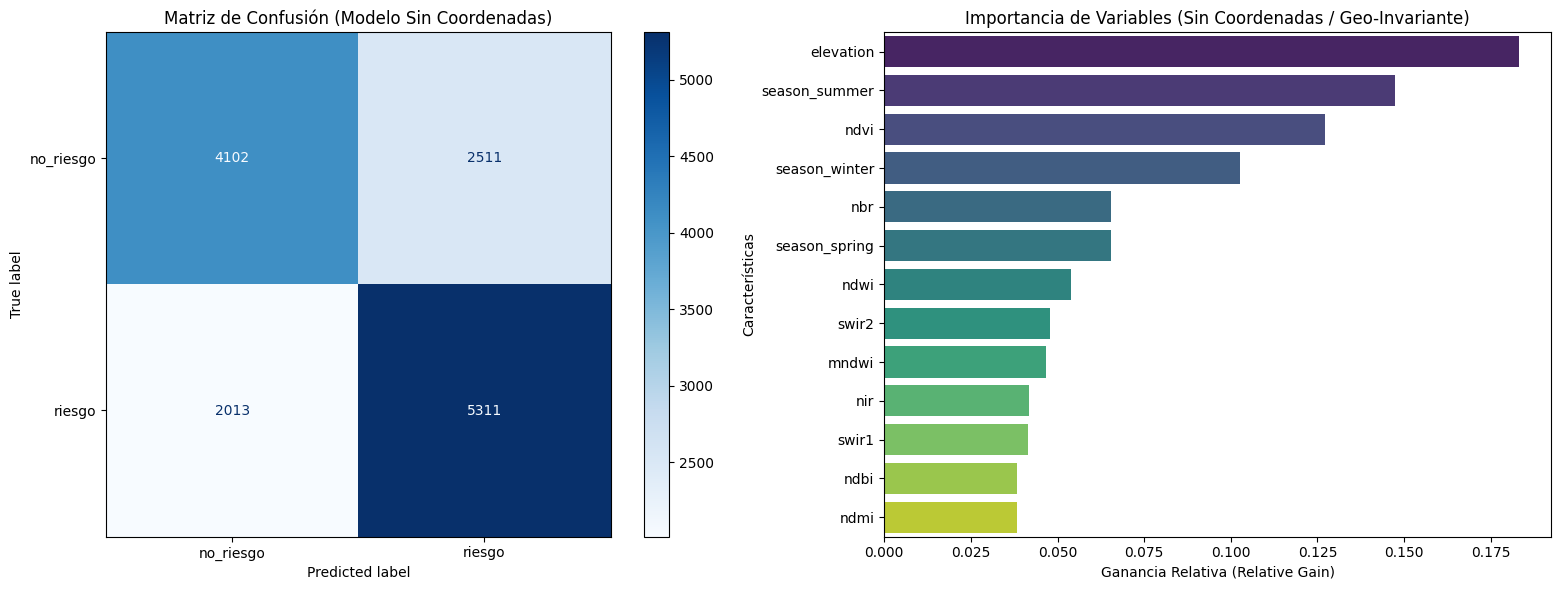

In [2]:
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# 1. LOAD AND PREPARE DATASET (COORDINATE-FREE)
# ============================================================

# Load the dataset
df = pd.read_csv('../data/processed/dataset_modeling.csv')

TARGET = 'uhi_risk'

# Remove raw coordinates to prevent spatial memorization/bias
NON_SPATIAL_FEATURES = [
    'elevation', 'mndwi', 'nbr', 'ndbi', 'ndmi', 'ndvi', 'ndwi', 
    'nir', 'swir1', 'swir2', 'season'
]

X = df[NON_SPATIAL_FEATURES]
y = df[TARGET]

# ============================================================
# 2. ENCODE CATEGORICAL VARIABLES (One-Hot Encoding)
# ============================================================
X = pd.get_dummies(X, columns=['season'], drop_first=True)

# Save the updated features list for the importance plot
UPDATED_FEATURES = X.columns.tolist()

# ============================================================
# 3. TRAIN-TEST SPLIT
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

# ============================================================
# 4. OPTIMIZED MODEL INITIALIZATION & TRAINING
# ============================================================
# Utilizing the optimized parameters found during your tuning session
xgb_opt_ns = xgb.XGBClassifier(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=5,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=2,
    reg_alpha=1,
    gamma=0,
    random_state=42,
    n_jobs=-1,
    eval_metric="logloss"
)

xgb_opt_ns.fit(X_train, y_train)

# ============================================================
# 5. EVALUATION
# ============================================================
y_pred_ns = xgb_opt_ns.predict(X_test)
y_probs_ns = xgb_opt_ns.predict_proba(X_test)[:, 1]

print("=======================================================")
print("REPORTE DE CLASIFICACIÓN (MODELO SIN COORDENADAS)")
print("=======================================================")
print(classification_report(y_test, y_pred_ns, target_names=["no_riesgo", "riesgo"]))
print(f"Área Bajo la Curva ROC (AUC-ROC): {roc_auc_score(y_test, y_probs_ns):.4f}\n")

# ============================================================
# 6. VISUALIZATION (CONFUSION MATRIX & FEATURE IMPORTANCE)
# ============================================================
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Plot Confusion Matrix
cm_ns = confusion_matrix(y_test, y_pred_ns)
disp_ns = ConfusionMatrixDisplay(confusion_matrix=cm_ns, display_labels=["no_riesgo", "riesgo"])
disp_ns.plot(ax=ax[0], cmap="Blues", values_format="d")
ax[0].set_title("Matriz de Confusión (Modelo Sin Coordenadas)")

# Plot Feature Importance
importances_ns = xgb_opt_ns.feature_importances_
indices_ns = np.argsort(importances_ns)[::-1]

sns.barplot(
    x=importances_ns[indices_ns], 
    y=np.array(UPDATED_FEATURES)[indices_ns], 
    ax=ax[1], 
    palette="viridis"
)
ax[1].set_title("Importancia de Variables (Sin Coordenadas / Geo-Invariante)")
ax[1].set_xlabel("Ganancia Relativa (Relative Gain)")
ax[1].set_ylabel("Características")

plt.tight_layout()
plt.show()

Iniciando optimización por búsqueda aleatoria para modelo sin coordenadas...
Fitting 4 folds for each of 15 candidates, totalling 60 fits



Mejores parámetros encontrados para el modelo sin coordenadas:
 -> subsample: 0.9
 -> reg_lambda: 1
 -> reg_alpha: 1
 -> n_estimators: 600
 -> max_depth: 7
 -> learning_rate: 0.02
 -> gamma: 0.5
 -> colsample_bytree: 0.8

REPORTE DE CLASIFICACIÓN (MODELO OPTIMIZADO SIN ESPACIO)
              precision    recall  f1-score   support

   no_riesgo       0.68      0.62      0.65      6613
      riesgo       0.68      0.73      0.71      7324

    accuracy                           0.68     13937
   macro avg       0.68      0.68      0.68     13937
weighted avg       0.68      0.68      0.68     13937

Área Bajo la Curva ROC (AUC-ROC) Optimizado Final: 0.7454



array([<Axes: title={'center': 'Matriz de Confusión - XGBoost Sin Coordenadas (Optimizado)'}, xlabel='Predicted label', ylabel='True label'>,
       <Axes: >], dtype=object)

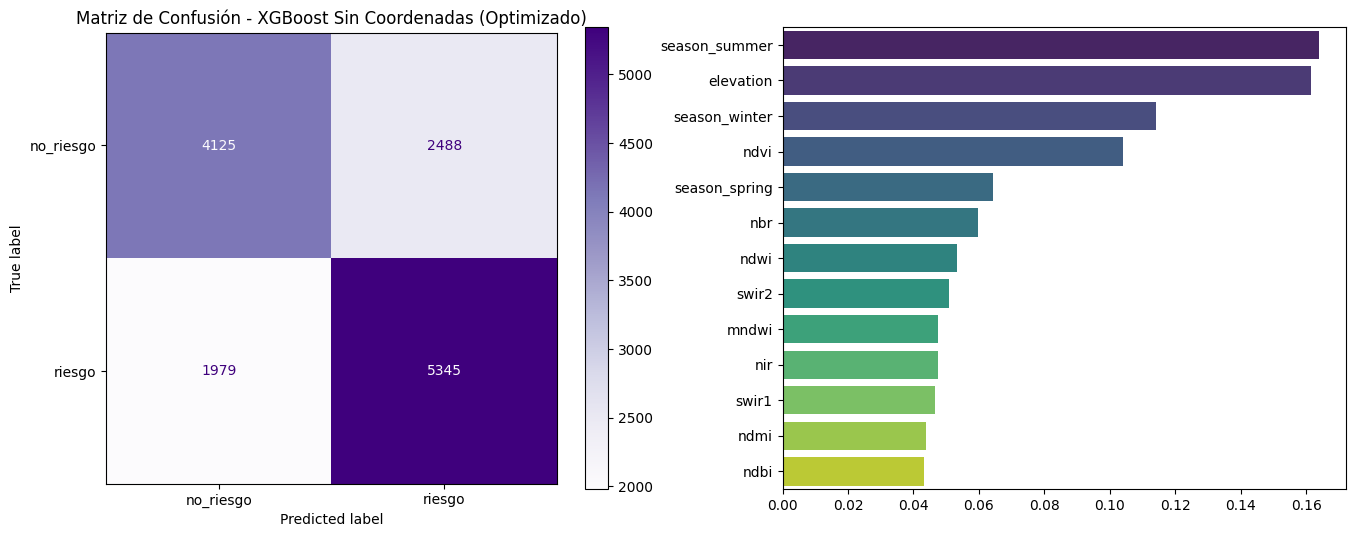

In [5]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
# ============================================================
# 5. HYPERPARAMETER TUNING FOR GEO-INVARIANT MODEL (Randomized Search)
# ============================================================

# Definimos una nueva rejilla adaptada al nuevo espacio de características.
# Incrementamos levemente max_depth para compensar la falta de coordenadas
# y permitir mejores interacciones entre índices y topografía.
param_dist = {
    'n_estimators': [400, 600, 800, 1000],
    'learning_rate': [0.02, 0.03, 0.05, 0.08],
    'max_depth': [5, 6, 7, 8],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'gamma': [0, 0.1, 0.2, 0.5],
    'reg_alpha': [0, 0.1, 1, 5],
    'reg_lambda': [1, 2, 5, 10]
}

# Usamos StratifiedKFold para mantener el balance de clases en los folds de validación
cv_strategy = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)

print("Iniciando optimización por búsqueda aleatoria para modelo sin coordenadas...")
xgb_search = RandomizedSearchCV(
    estimator=xgb.XGBClassifier(random_state=42, n_jobs=-1, eval_metric="logloss"),
    param_distributions=param_dist,
    n_iter=15,               # Evaluamos 15 combinaciones aleatorias
    scoring='roc_auc',       # Optimizamos para maximizar el AUC-ROC
    cv=cv_strategy,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

xgb_search.fit(X_train, y_train)
best_xgb_ns = xgb_search.best_estimator_

print("\nMejores parámetros encontrados para el modelo sin coordenadas:")
for param, value in xgb_search.best_params_.items():
    print(f" -> {param}: {value}")

# ============================================================
# 6. EVALUACIÓN DEL MODELO OPTIMIZADO
# ============================================================
y_pred_ns_opt = best_xgb_ns.predict(X_test)
y_probs_ns_opt = best_xgb_ns.predict_proba(X_test)[:, 1]

print("\n" + "="*55)
print("REPORTE DE CLASIFICACIÓN (MODELO OPTIMIZADO SIN ESPACIO)")
print("=======================================================")
print(classification_report(y_test, y_pred_ns_opt, target_names=["no_riesgo", "riesgo"]))
auc_opt_ns = roc_auc_score(y_test, y_probs_ns_opt)
print(f"Área Bajo la Curva ROC (AUC-ROC) Optimizado Final: {auc_opt_ns:.4f}\n")

# ============================================================
# 7. VISUALIZACIÓN DE RESULTADOS
# ============================================================
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Matriz de Confusión
cm_ns = confusion_matrix(y_test, y_pred_ns_opt)
disp_ns = ConfusionMatrixDisplay(confusion_matrix=cm_ns, display_labels=["no_riesgo", "riesgo"])
disp_ns.plot(ax=ax[0], cmap="Purples", values_format="d")
ax[0].set_title("Matriz de Confusión - XGBoost Sin Coordenadas (Optimizado)")

# Importancia de Variables
importances_ns = best_xgb_ns.feature_importances_
indices_ns = np.argsort(importances_ns)[::-1]

sns.barplot(
    x=importances_ns[indices_ns], 
    y=np.array(UPDATED_FEATURES)[indices_ns], 
    ax=ax[1], 
    palette="viridis"
)
ax